<a href="https://colab.research.google.com/github/Chaitanya081/DSA0205_Computer-Vision-with-OpenCV/blob/main/CO3_AT1(DSA0205).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Image Preprocessing Pipeline: Noise Removal, Resizing, and Normalization

Saving image.jpg to image (2).jpg
Image: image (2).jpg
Shape: (255, 197, 3)


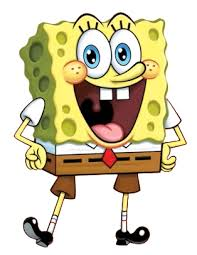

Original:


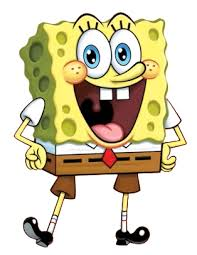

Resized:


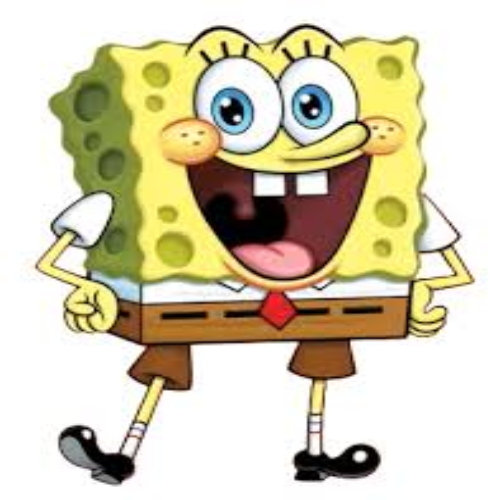

Noisy:


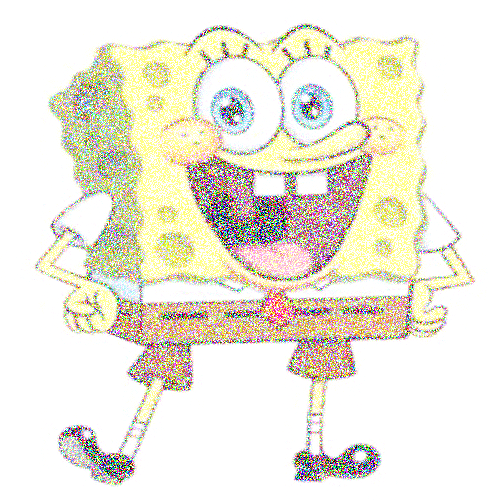

Denoised:


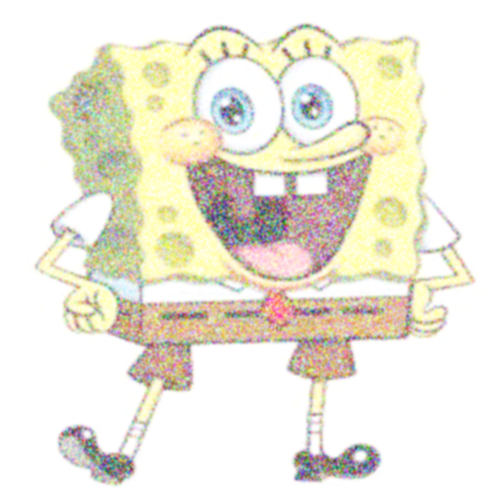

Normalized:


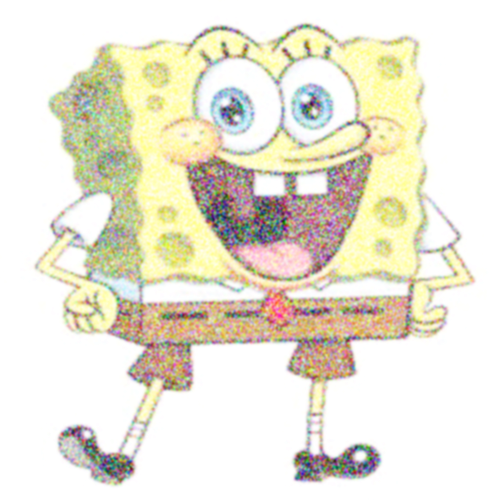

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename)

print("Image:", filename)
print("Shape:", img.shape)

cv2_imshow(img)
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread(filename)

resized = cv2.resize(img, (500, 500))

noise = np.random.normal(0, 25, resized.shape).astype(np.uint8)
noisy = cv2.add(resized, noise)

denoised = cv2.GaussianBlur(noisy, (5, 5), 0)

normalized = cv2.normalize(
    denoised.astype(np.float32),
    None,
    0,
    1,
    cv2.NORM_MINMAX
)

print("Original:")
cv2_imshow(img)

print("Resized:")
cv2_imshow(resized)

print("Noisy:")
cv2_imshow(noisy)

print("Denoised:")
cv2_imshow(denoised)

print("Normalized:")
cv2_imshow((normalized * 255).astype(np.uint8))

2. Comparative Study of Image Representation Formats (RGB, Grayscale, HSV)

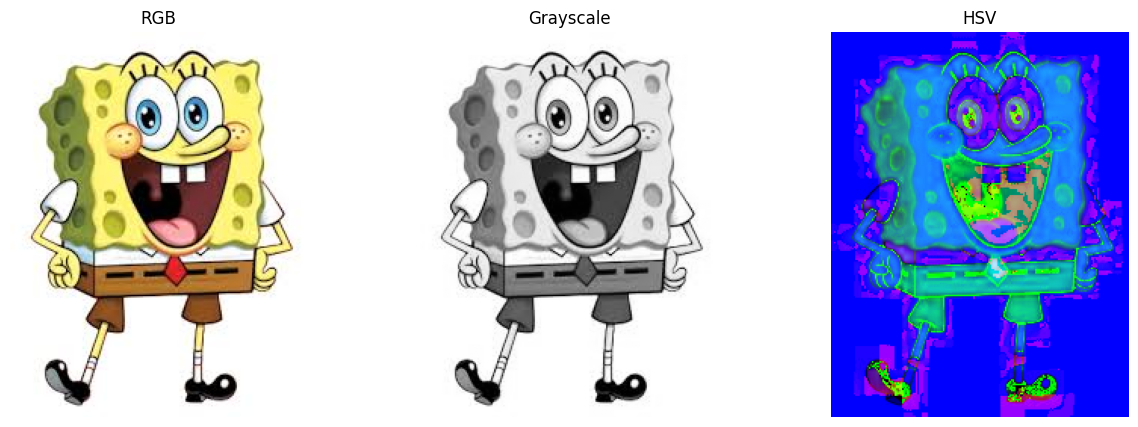

In [6]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(filename)

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

3. Edge Detection Using the Sobel Operator

Sobel X


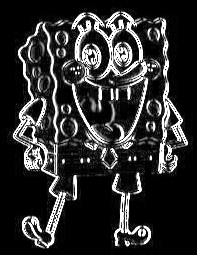

Sobel Y


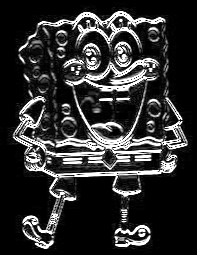

Combined Sobel


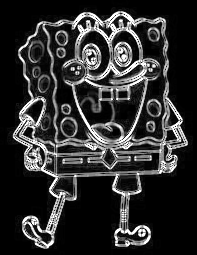

In [7]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

sobel = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

print("Sobel X")
cv2_imshow(sobel_x)

print("Sobel Y")
cv2_imshow(sobel_y)

print("Combined Sobel")
cv2_imshow(sobel)

4. Canny Edge Detection and Parameter Tuning

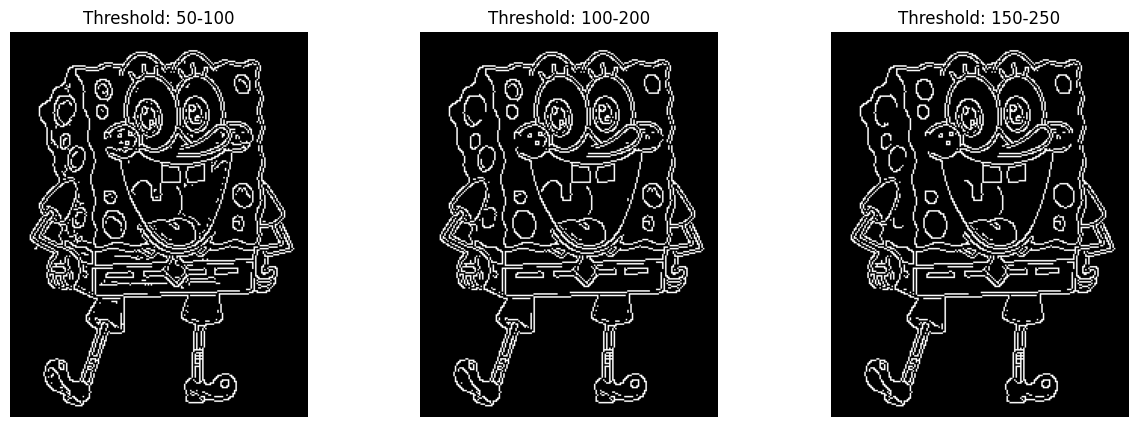

In [8]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges1 = cv2.Canny(gray, 50, 100)
edges2 = cv2.Canny(gray, 100, 200)
edges3 = cv2.Canny(gray, 150, 250)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(edges1, cmap="gray")
plt.title("Threshold: 50-100")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges2, cmap="gray")
plt.title("Threshold: 100-200")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges3, cmap="gray")
plt.title("Threshold: 150-250")
plt.axis("off")

plt.show()

5. Harris Corner Detection

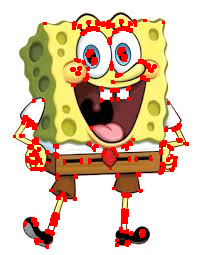

In [9]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

corners = cv2.cornerHarris(
    gray,
    blockSize=2,
    ksize=3,
    k=0.04
)

corners = cv2.dilate(corners, None)

result = cv2.imread(filename)

result[corners > 0.01 * corners.max()] = [0, 0, 255]

cv2_imshow(result)

6. Corner Response Analysis Across Varying Thresholds

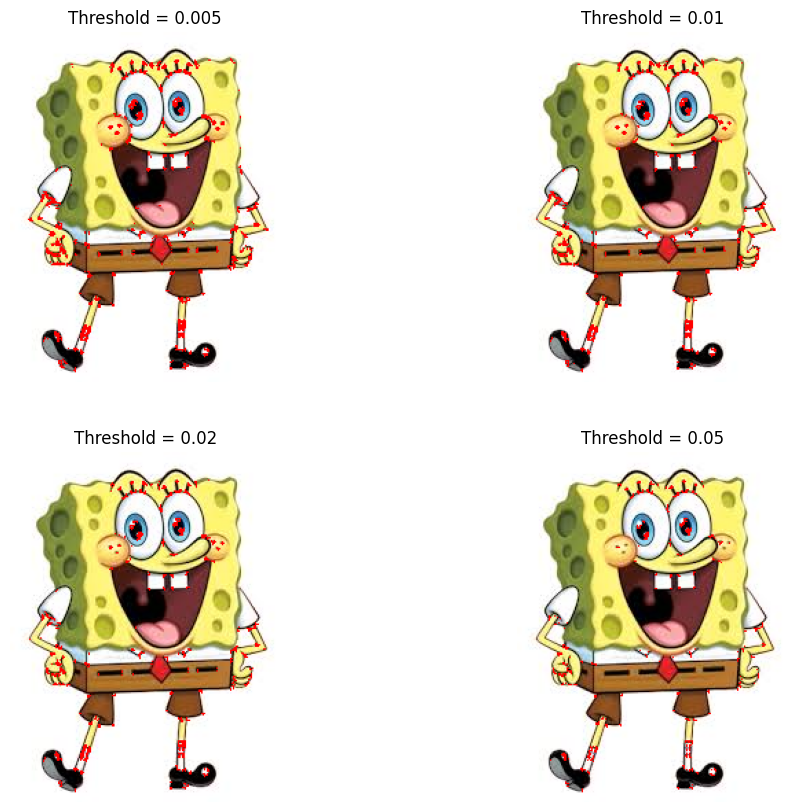

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

response = cv2.cornerHarris(
    gray,
    2,
    3,
    0.04
)

thresholds = [0.005, 0.01, 0.02, 0.05]

plt.figure(figsize=(12, 10))

for i, threshold in enumerate(thresholds):

    result = img.copy()

    result[response > threshold * response.max()] = [0, 0, 255]

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(result)
    plt.title("Threshold = " + str(threshold))
    plt.axis("off")

plt.show()

7. Line Detection Using Hough Transform

Detected Lines:


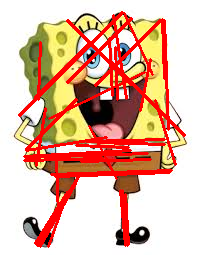

In [12]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=50,
    minLineLength=50,
    maxLineGap=10
)

result = img.copy()

if lines is not None:

    for line in lines:


        x1, y1, x2, y2 = np.array(line).flatten()

        # Draw line
        cv2.line(
            result,
            (x1, y1),
            (x2, y2),
            (0, 0, 255),
            2
        )

print("Detected Lines:")
cv2_imshow(result)

8.Circle Detection Using the Hough Circle Transform.

Number of circles detected: 10


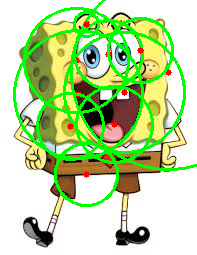

In [13]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.GaussianBlur(gray, (9, 9), 2)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=100,
    param2=30,
    minRadius=10,
    maxRadius=100
)

result = img.copy()

if circles is not None:

    circles = np.uint16(np.around(circles))

    for circle in circles[0]:

        x, y, r = circle

        cv2.circle(
            result,
            (x, y),
            r,
            (0, 255, 0),
            2
        )

        cv2.circle(
            result,
            (x, y),
            3,
            (0, 0, 255),
            -1
        )

    print("Number of circles detected:", len(circles[0]))

else:
    print("No circles detected.")

cv2_imshow(result)

9.Scale-Invariant Feature Matching Using SIFT Keypoints and Descriptors

Saving image.jpg to image (4).jpg
Original Image:


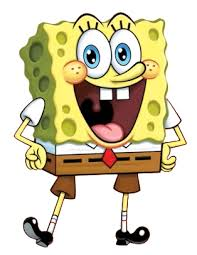

Rotated Image:


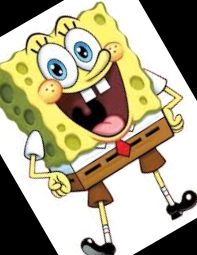

SIFT Keypoints - Original Image:


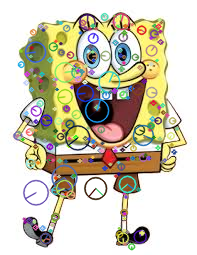

SIFT Keypoints - Rotated Image:


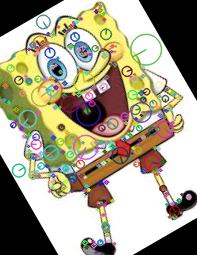

Number of keypoints in Image 1: 339
Number of keypoints in Image 2: 403
Descriptor shape - Image 1: (339, 128)
Descriptor shape - Image 2: (403, 128)


In [15]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img1 = cv2.imread(filename)

if img1 is None:
    print("Error: Image could not be read.")
else:

    height, width = img1.shape[:2]
    center = (width // 2, height // 2)

    matrix = cv2.getRotationMatrix2D(
        center,
        30,
        1.0
    )

    img2 = cv2.warpAffine(
        img1,
        matrix,
        (width, height)
    )

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # Draw keypoints
    output1 = cv2.drawKeypoints(
        img1,
        kp1,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    output2 = cv2.drawKeypoints(
        img2,
        kp2,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    # Display results
    print("Original Image:")
    cv2_imshow(img1)

    print("Rotated Image:")
    cv2_imshow(img2)

    print("SIFT Keypoints - Original Image:")
    cv2_imshow(output1)

    print("SIFT Keypoints - Rotated Image:")
    cv2_imshow(output2)

    print("Number of keypoints in Image 1:", len(kp1))
    print("Number of keypoints in Image 2:", len(kp2))
    print("Descriptor shape - Image 1:", des1.shape)
    print("Descriptor shape - Image 2:", des2.shape)

10.SIFT Feature Matching with Distance-Ratio Test

Saving image.jpg to image (5).jpg
Keypoints in Image 1: 339
Keypoints in Image 2: 403
Total matches: 339
Good matches: 193


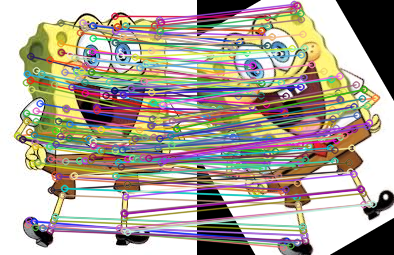

In [16]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img1 = cv2.imread(filename)

height, width = img1.shape[:2]
center = (width // 2, height // 2)

matrix = cv2.getRotationMatrix2D(center, 30, 1.0)

img2 = cv2.warpAffine(
    img1,
    matrix,
    (width, height)
)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(
    des1,
    des2,
    k=2
)

good_matches = []

for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

print("Keypoints in Image 1:", len(kp1))
print("Keypoints in Image 2:", len(kp2))
print("Total matches:", len(matches))
print("Good matches:", len(good_matches))

cv2_imshow(result)

11.Dimensionality Reduction Using PCA

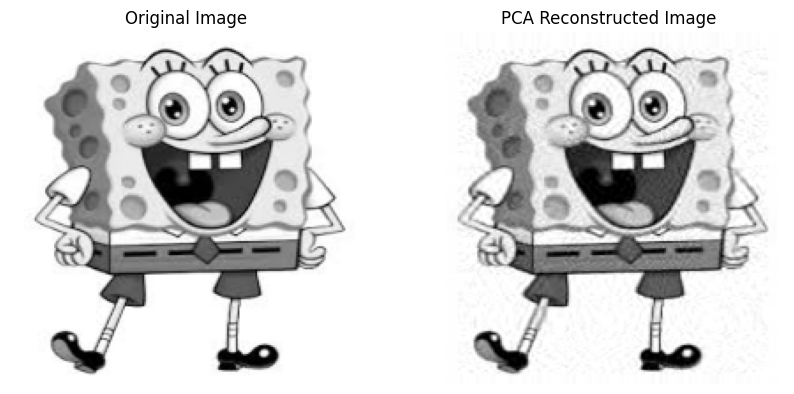

Original dimensions: (200, 200)
Reduced dimensions: (200, 50)
Number of principal components: 50


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (200, 200))

data = np.float32(img)

mean, eigenvectors = cv2.PCACompute(
    data,
    mean=None,
    maxComponents=50
)

projected = cv2.PCAProject(
    data,
    mean,
    eigenvectors
)

reconstructed = cv2.PCABackProject(
    projected,
    mean,
    eigenvectors
)

reconstructed = np.uint8(
    np.clip(reconstructed, 0, 255)
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("PCA Reconstructed Image")
plt.axis("off")

plt.show()

print("Original dimensions:", data.shape)
print("Reduced dimensions:", projected.shape)
print("Number of principal components:", eigenvectors.shape[0])

12.End-to-End Feature Pipeline: Preprocessing to Matched Keypoints

Saving image.jpg to image (6).jpg
Image 1 keypoints: 639
Image 2 keypoints: 592
Total matches: 639
Good matches: 443
Original Image


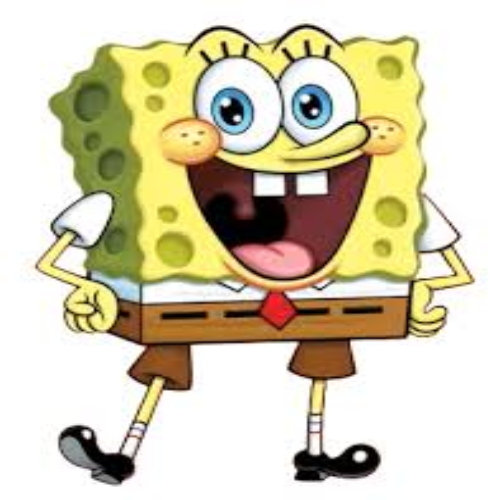

Preprocessed Image 1


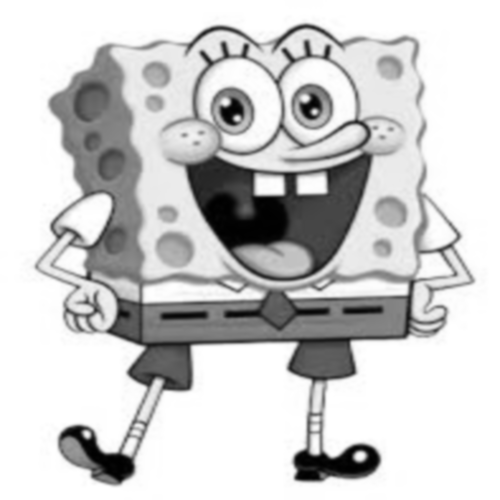

Preprocessed Image 2


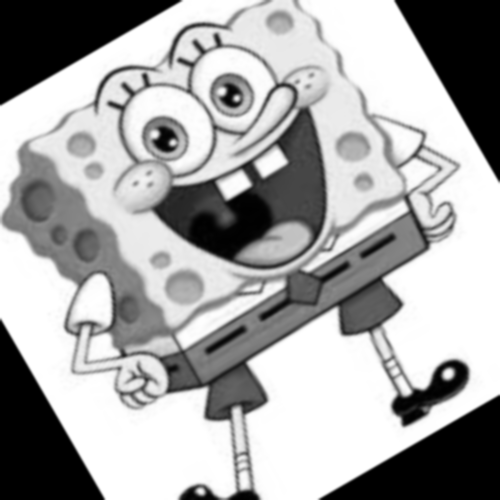

Matched Keypoints


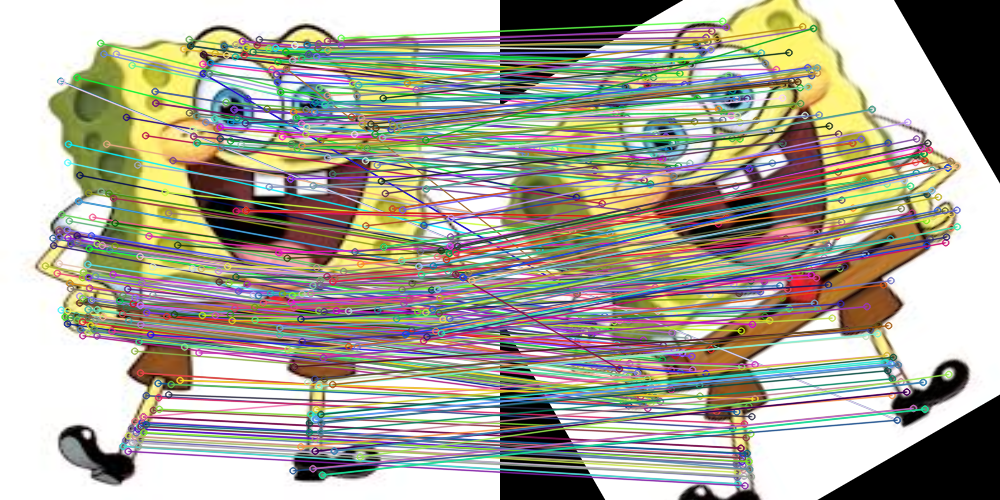

In [18]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img1 = cv2.imread(filename)

height, width = img1.shape[:2]

img1 = cv2.resize(img1, (500, 500))

center = (250, 250)

matrix = cv2.getRotationMatrix2D(
    center,
    30,
    1.0
)

img2 = cv2.warpAffine(
    img1,
    matrix,
    (500, 500)
)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

gray1 = cv2.GaussianBlur(
    gray1,
    (5, 5),
    0
)

gray2 = cv2.GaussianBlur(
    gray2,
    (5, 5),
    0
)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(
    gray1,
    None
)

kp2, des2 = sift.detectAndCompute(
    gray2,
    None
)

bf = cv2.BFMatcher()

matches = bf.knnMatch(
    des1,
    des2,
    k=2
)

good_matches = []

for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

print("Image 1 keypoints:", len(kp1))
print("Image 2 keypoints:", len(kp2))
print("Total matches:", len(matches))
print("Good matches:", len(good_matches))

print("Original Image")
cv2_imshow(img1)

print("Preprocessed Image 1")
cv2_imshow(gray1)

print("Preprocessed Image 2")
cv2_imshow(gray2)

print("Matched Keypoints")
cv2_imshow(result)